Overview
<p>
Imagine you are working on a project that involves processing a large collection of text documents, such as research papers, legal documents, or customer service logs. Your task is to develop a system that can quickly retrieve the most relevant segments of text based on a user's query. Traditional keyword-based search methods might not be sufficient, as they often fail to capture the nuanced meanings and contexts within the documents. To address this challenge, you can use different types of retrievers based on LangChain.
<p><p>
Using retrievers is crucial for several reasons:
<p>
Efficiency: Retrievers enable fast and efficient retrieval of relevant information from large datasets, saving time and computational resources.
<p>
Accuracy: By leveraging advanced retrieval techniques, these tools can provide more accurate and contextually relevant results compared to traditional search methods.
Versatility: Different retrievers can be tailored to specific use cases, making them adaptable to various types of text data and query requirements.
<p>
Context awareness: Some retrievers, such as the Parent Document Retriever, can consider the broader context of the document, enhancing the relevance of the retrieved segments.
<p>
In this lab, you will learn how to use various retrievers to efficiently extract relevant document segments from text using LangChain. You will learn about four types of retrievers: Vector Store-backed Retriever, Multi-Query Retriever, Self-Querying Retriever, and Parent Document Retriever. You will also learn the differences between these retrievers and understand the appropriate situations in which to use each one. By the end of this lab, you will be equipped with the skills to implement and utilize these retrievers in your projects.
<p>
<p>
Objectives
<p>
After completing this lab, you will be able to:
<p>
<ul>
<li>Use various types of retrievers to efficiently extract relevant document segments from text, leveraging LangChain's capabilities.</li>
<li>
Apply the Vector Store-backed Retriever to solve problems involving semantic similarity and relevance in large text datasets.</li>
<li>
Utilize the Multi-Query Retriever to address situations where multiple query variations are needed to capture comprehensive results.
</li>
<li>
Implement the Self-Querying Retriever to automatically generate and refine queries, enhancing the accuracy of information retrieval.
</li>
<li>
Employ the Parent Document Retriever to maintain context and relevance by considering the broader context of the parent document.
</li>
</ul>

In [2]:
!pip install "ibm-watsonx-ai==1.1.2" 
!pip install "langchain==0.2.1" 
!pip install "langchain-ibm==0.1.11"
!pip install "langchain-community==0.2.1" 
!pip install "chromadb==0.4.24" 
!pip install "pypdf==4.3.1" 
!pip install "lark==1.1.9" 
!pip install 'posthog<6.0.0' 

  Using cached ibm_watsonx_ai-1.1.2-py3-none-any.whl.metadata (6.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached pandas-2.1.4-cp312-cp312-win_amd64.whl.metadata (18 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached lomond-0.3.3-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached ibm_cos_sdk-2.13.6-py3-none-any.whl
  Using cached importlib_metadata-9.0.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached ibm_cos_sdk_core-2.13.6-py3-none-any.whl
  Using cached ibm_cos_sdk_s3transfer-2.13.6-py3-none-any.whl
  Using cached jmespath-1.0.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached requests-2.32.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tz


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-win_amd64.whl.metadata (8.5 kB)
  Using cached langchain_core-0.2.43-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_text_splitters-0.2.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp312-cp312-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.2-cp312-cp312-win_amd64.whl.metadata (97 kB)
  Using


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached langchain_ibm-0.1.11-py3-none-any.whl.metadata (5.2 kB)
Using cached langchain_ibm-0.1.11-py3-none-any.whl (19 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached marshmallow-3.26.2-py3-none-any.whl.metadata (7.3 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 30.3 MB/s eta 0:00:00
Using cached dataclasses_json-0.6.7-py3-none-any.whl (28 kB)
Using cached marshmallow-3.26.2-py3-none-any.whl (50 kB)
Using cached typing_inspect-0.9.0-py3-none-any.whl (8.8 kB)
Using cached mypy_extensions-1.1.0-py3-none-any.whl (5.0 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached chromadb-0.4.24-py3-none-any.whl.metadata (7.3 kB)
  Using cached build-1.5.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached chroma_hnswlib-0.7.3-cp312-cp312-win_amd64.whl
  Using cached uvicorn-0.51.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached onnxruntime-1.27.0-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl.metadata (10 kB)
  Using cached pypika-0.51.1-py2.py3-none-any.whl.metadata (51 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached grpcio-1.82.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached bcrypt-5.0.0-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached typer-0.27.0-py3-none-any.whl.metadata (15 kB)
  Using cached kubernetes-36.0.3-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached mmh3-5.2.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached pyproject_hooks-1.2.0-p


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pypdf-4.3.1-py3-none-any.whl.metadata (7.4 kB)
Using cached pypdf-4.3.1-py3-none-any.whl (295 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
The system cannot find the file specified.


In [4]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

Creating a retriever model
<p>
The following steps are involved to create a retriever model using LangChain:

Building LLMs

Splitting documents into chunks

Building an embedding model

Retrieving related knowledge from text

<p>
Build the LLM
<p>
Develop or select a pre-trained language model that can understand and generate human-like text. This model serves as the foundation for processing and interpreting language data.

In [3]:
from ibm_watsonx_ai.foundation_models import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models.extensions.langchain import WatsonxLLM

d:\code\pythondemo\notebooks\agents\chroma\rag_with_vector_database\.rag_with_vector_database\Lib\site-packages\ibm_watsonx_ai\foundation_models\extensions\langchain\llm.py:63: WatsonxLLMDeprecationWarning: ibm_watsonx_ai.foundation_models.extensions.langchain.WatsonxLLM is deprecated and will not be supported in the future. Please import from langchain-ibm instead.
To install langchain-ibm run `pip install -U langchain-ibm`.
  _raise_watsonxllm_deprecation_warning()


In [5]:
# connect to watson-x

def llm():
    model_id = 'mistralai/mistral-small-3-1-24b-instruct-2503'
    
    parameters = {
        GenParams.MAX_NEW_TOKENS: 256,  # this controls the maximum number of tokens in the generated output
        GenParams.TEMPERATURE: 0.5, # this randomness or creativity of the model's responses
    }
    
    credentials = {
        "url": "https://us-south.ml.cloud.ibm.com"
    }
    
    
    project_id = "skills-network"
    
    model = ModelInference(
        model_id=model_id,
        params=parameters,
        credentials=credentials,
        project_id=project_id
    )
    
    mixtral_llm = WatsonxLLM(model = model)
    return mixtral_llm

Use the text splitter
<p>
Break down large documents into smaller, manageable pieces or chunks. This helps in processing and analyzing the text more efficiently, allowing the model to focus on specific sections rather than being overwhelmed by the entire document.

In [6]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

def text_splitter(data, chunk_size, chunk_overlap):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )
    chunks = text_splitter.split_documents(data)
    return chunks

Create the embedding model
<p>
Create or utilize an embedding model to convert chunks of text into numerical vectors. These vectors represent the semantic meaning of the text, enabling the model to compare and retrieve relevant information based on similarity. The following code demonstrates how to build an embedding model using the watsonx.ai package.

For this project, the ibm/slate-125m-english-rtrvr-v2 embedding model is used.

In [16]:
from ibm_watsonx_ai.metanames import EmbedTextParamsMetaNames
from langchain_ibm import WatsonxEmbeddings
def watsonx_embedding():
    embed_params = {
        EmbedTextParamsMetaNames.TRUNCATE_INPUT_TOKENS: 3,
        EmbedTextParamsMetaNames.RETURN_OPTIONS: {"input_text": True},
    }
    
    watsonx_embedding = WatsonxEmbeddings(
        model_id="ibm/granite-embedding-278m-multilingual",
        url="https://us-south.ml.cloud.ibm.com",
        project_id="skills-network",
        params=embed_params,
    )
    return watsonx_embedding

Use Retrievers
<p>
A retriever is an interface designed to return documents based on an unstructured query. Unlike a vector store, which stores and retrieves documents, a retriever's primary function is to find and return relevant documents. While vector stores can serve as the backbone of a retriever, there are various other types of retrievers that can be used as well.
<p>
Retrievers take a string query as input and output a list of Documents.
<p>
Vector Store-Backed Retriever
<p>
A vector store retriever is a type of retriever that utilizes a vector store to fetch documents. It acts as a lightweight wrapper around the vector store class, enabling it to conform to the retriever interface. This retriever leverages the search methods implemented by the vector store, such as similarity search and Maximum Marginal Relevance (MMR), to query texts stored within it.







Before demonstrating this retriever, you need to load some example text. A .txt document has been prepared for you.

In [12]:
!curl -o companypolicies.txt https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/MZ9z1lm-Ui3YBp3SYWLTAQ/companypolicies.txt

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  15660 100  15660   0      0  14993      0   00:01   00:01              0
100  15660 100  15660   0      0  14990      0   00:01   00:01              0
100  15660 100  15660   0      0  14987      0   00:01   00:01              0


In [13]:
# Use TextLoader to load the document.

from langchain_community.document_loaders import TextLoader
loader = TextLoader("companypolicies.txt")
txt_data = loader.load()

# Let's take a look at this document. This is a document about different policies in a company.

txt_data

[Document(metadata={'source': 'companypolicies.txt'}, page_content="1.\tCode of Conduct\n\nOur Code of Conduct outlines the fundamental principles and ethical standards that guide every member of our organization. We are committed to maintaining a workplace that is built on integrity, respect, and accountability.\nIntegrity: We hold ourselves to the highest ethical standards. This means acting honestly and transparently in all our interactions, whether with colleagues, clients, or the broader community. We respect and protect sensitive information, and we avoid conflicts of interest.\nRespect: We embrace diversity and value each individual's contributions. Discrimination, harassment, or any form of disrespectful behavior is unacceptable. We create an inclusive environment where differences are celebrated and everyone is treated with dignity and courtesy.\nAccountability: We take responsibility for our actions and decisions. We follow all relevant laws and regulations, and we strive to 

In [14]:
# Split txt_data into chunks. chunk_size = 200, chunk_overlap = 20 has been set.

chunks_txt = text_splitter(txt_data, 200, 20)


# Store the embeddings into a ChromaDB


from langchain.vectorstores import Chroma

vectordb = Chroma.from_documents(chunks_txt, watsonx_embedding())






ValidationError: 1 validation error for WatsonxEmbeddings
__root__
  Did not find apikey, please add an environment variable `WATSONX_APIKEY` which contains it, or pass `apikey` as a named parameter. (type=value_error)

Simple similarity search
<p>
Here is an example of a simple similarity search based on the vector database.
<p>
For this demonstration, the query has been set to "email policy".
<p>

In [ ]:
query = "email policy"
retriever = vectordb.as_retriever()
docs = retriever.invoke(query)
# By default, the number of retrieval results is four, and they are ranked by similarity level.
 


In [17]:
docs

NameError: name 'docs' is not defined

output will be matching chunks based on vector cosine distance - 
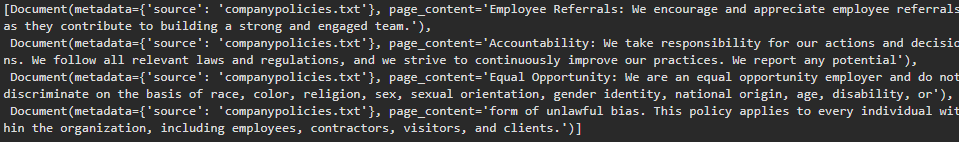

In [18]:
# You can also specify search kwargs like k to limit the retrieval results.

retriever = vectordb.as_retriever(search_kwargs={"k": 1})
docs = retriever.invoke(query)
docs

NameError: name 'vectordb' is not defined

Output will be - 

![
    
](attachment:image.png)
MMR search
<p>
MMR in vector stores is a technique used to balance the relevance and diversity of retrieved results. It selects documents that are both highly relevant to the query and minimally similar to previously selected documents. This approach helps to avoid redundancy and ensures a more comprehensive coverage of different aspects of the query.
<p>
The following code is showing how to conduct an MMR search in a vector database. You just need to sepecify search_type="mmr".

In [19]:
retriever = vectordb.as_retriever(search_type="mmr")
docs = retriever.invoke(query)
docs

NameError: name 'vectordb' is not defined

output will be - 
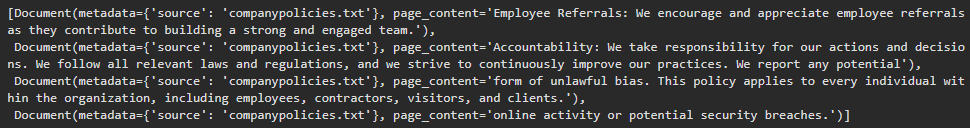

<p>
You can also set a retrieval method that defines a similarity score threshold, returning only documents with a score above that threshold.

In [20]:
retriever = vectordb.as_retriever(
    search_type="similarity_score_threshold", search_kwargs={"score_threshold": 0.4}
)
docs = retriever.invoke(query)
docs

NameError: name 'vectordb' is not defined

output will be -

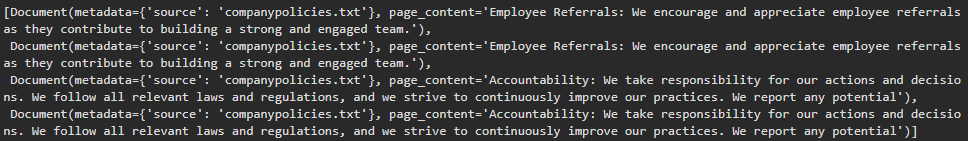

Multi-Query Retriever
<p>
Distance-based vector database retrieval represents queries in high-dimensional space and finds similar embedded documents based on "distance". However, retrieval results may vary with subtle changes in query wording or if the embeddings do not accurately capture the data's semantics.
<p>
The MultiQueryRetriever addresses this by using an LLM to generate multiple queries from different perspectives for a given user input query. It first uses an LLM to generate multiple queries from different perspectives based on the user's input query. For each generated query, it retrieves relevant documents and then returns the union of these results. For each query, it retrieves a set of relevant documents and then takes the unique union of these results to form a larger set of potentially relevant documents. By generating multiple perspectives on the same question, the MultiQueryRetriever can potentially overcome some limitations of distance-based retrieval, resulting in a richer and more diverse set of results.
<p>
The following picture shows the difference between retrievers solely based on distance and the Multi-Query Retriever.

In [21]:
# A PDF document has been prepared to demonstrate this Multi-Query Retriever.

from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ioch1wsxkfqgfLLgmd-6Rw/langchain-paper.pdf")
pdf_data = loader.load()

# Let's take a look at the first page of this paper. This paper is talking about the LangChain framework.

pdf_data[1]

Document(metadata={'source': 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ioch1wsxkfqgfLLgmd-6Rw/langchain-paper.pdf', 'page': 1}, page_content='LangChain helps us to unlock the ability to harness the \nLLM’s immense potential in tasks such as document analysis, \nchatbot development, code analysis, and countless other \napplications. Whether your desire is to unlock deeper natural \nlanguage understanding , enhance data, or circumvent \nlanguage barriers through translation, LangChain is ready to \nprovide the tools and programming support you need to do \nwithout it that it is not only difficult but also fresh for you . Its \ncore functionalities encompass:  \n1. Context -Aware Capabilities: LangChain facilitates the \ndevelopment of applications that are inherently \ncontext -aware. This means that these applications can \nconnect to a language model and draw from various \nsources of context, such as prompt instructions, a  few-\nshot examples, or existing co

In [22]:
# Split the document and store the embeddings into a vector database.

# Split
chunks_pdf = text_splitter(pdf_data, 500, 20)

# VectorDB
ids = vectordb.get()["ids"]
vectordb.delete(ids) # We need to delete existing embeddings from previous documents and then store current document embeddings in.
vectordb = Chroma.from_documents(documents=chunks_pdf, embedding=watsonx_embedding())

NameError: name 'vectordb' is not defined

In [23]:
# The MultiQueryRetriever function from LangChain is used.
from langchain.retrievers.multi_query import MultiQueryRetriever

query = "What does the paper say about langchain?"

retriever = MultiQueryRetriever.from_llm(
    retriever=vectordb.as_retriever(), llm=llm()
)

NameError: name 'vectordb' is not defined

In [24]:
# Set logging for the queries.

import logging

logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

docs = retriever.invoke(query)
docs


# From the log results, you can see that the LLM generated three additional queries from different perspectives based on the given query.

# The returned results are the union of the results from each query.

NameError: name 'retriever' is not defined

Self-Querying Retriever
<p>
A Self-Querying Retriever, as the name suggests, has the ability to query itself. Specifically, given a natural language query, the retriever uses a query-constructing LLM chain to generate a structured query. It then applies this structured query to its underlying vector store. This enables the retriever to not only use the user-input query for semantic similarity comparison with the contents of stored documents but also to extract and apply filters based on the metadata of those documents.
<p>
The following code demonstrates how to use a Self-Querying Retriever.

In [25]:
from langchain_core.documents import Document
from langchain.chains.query_constructor.base import AttributeInfo
from langchain.retrievers.self_query.base import SelfQueryRetriever
from lark import lark

In [26]:
# A couple of document pieces have been prepared where the page_content contains descriptions of movies, and the meta_data includes different attributes for each movie, such as year, rating, genre, and director. These attributes are crucial in the Self-Querying Retriever, as the LLM will use the metadata information to apply filters during the retrieval process.

docs = [
    Document(
        page_content="A bunch of scientists bring back dinosaurs and mayhem breaks loose",
        metadata={"year": 1993, "rating": 7.7, "genre": "science fiction"},
    ),
    Document(
        page_content="Leo DiCaprio gets lost in a dream within a dream within a dream within a ...",
        metadata={"year": 2010, "director": "Christopher Nolan", "rating": 8.2},
    ),
    Document(
        page_content="A psychologist / detective gets lost in a series of dreams within dreams within dreams and Inception reused the idea",
        metadata={"year": 2006, "director": "Satoshi Kon", "rating": 8.6},
    ),
    Document(
        page_content="A bunch of normal-sized women are supremely wholesome and some men pine after them",
        metadata={"year": 2019, "director": "Greta Gerwig", "rating": 8.3},
    ),
    Document(
        page_content="Toys come alive and have a blast doing so",
        metadata={"year": 1995, "genre": "animated"},
    ),
    Document(
        page_content="Three men walk into the Zone, three men walk out of the Zone",
        metadata={
            "year": 1979,
            "director": "Andrei Tarkovsky",
            "genre": "thriller",
            "rating": 9.9,
        },
    ),
]

In [27]:
# Now you can instantiate your retriever. To do this, you'll need to provide some upfront information about the metadata fields that your documents support and a brief description of the document contents.
metadata_field_info = [
    AttributeInfo(
        name="genre",
        description="The genre of the movie. One of ['science fiction', 'comedy', 'drama', 'thriller', 'romance', 'action', 'animated']",
        type="string",
    ),
    AttributeInfo(
        name="year",
        description="The year the movie was released",
        type="integer",
    ),
    AttributeInfo(
        name="director",
        description="The name of the movie director",
        type="string",
    ),
    AttributeInfo(
        name="rating", description="A 1-10 rating for the movie", type="float"
    ),
]

In [28]:
# Store the document's embeddings into a vector database.

vectordb = Chroma.from_documents(docs, watsonx_embedding())

# Use the SelfQueryRetriever.

document_content_description = "Brief summary of a movie."

retriever = SelfQueryRetriever.from_llm(
    llm(),
    vectordb,
    document_content_description,
    metadata_field_info,
)

ValidationError: 1 validation error for WatsonxEmbeddings
__root__
  Did not find apikey, please add an environment variable `WATSONX_APIKEY` which contains it, or pass `apikey` as a named parameter. (type=value_error)

In [29]:
# Now you can actually try using your retriever.

# This example only specifies a filter
retriever.invoke("I want to watch a movie rated higher than 8.5")

NameError: name 'retriever' is not defined

output -
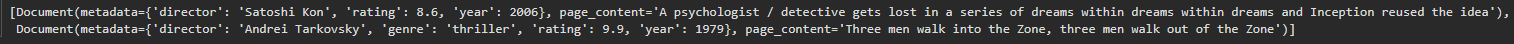

In [31]:

# This example specifies a query and a filter
retriever.invoke("Has Greta Gerwig directed any movies about women")



NameError: name 'retriever' is not defined

output -

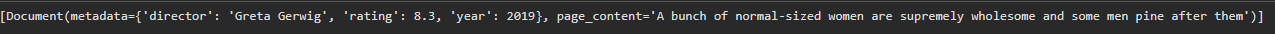

In [32]:
# When running the following cell, you might encounter some errors or blank content. This is because the LLM cannot get the answer at first. Don't worry; if you re-run it several times, you will get the answer.

# This example specifies a composite filter
retriever.invoke("What's a highly rated (above 8.5) science fiction film?")

NameError: name 'retriever' is not defined

Parent Document Retriever
<p>
When splitting documents for retrieval, there are often conflicting desires:
<p>
(1) You may want to have small documents so that their embeddings can most accurately reflect their meaning. If the documents are too long, the embeddings can lose meaning.
<p>
(2) You want to have long enough documents so that the context of each chunk is retained.
<p>
The ParentDocumentRetriever strikes that balance by splitting and storing small chunks of data. During retrieval, it first fetches the small chunks but then looks up the parent IDs for those chunks and returns those larger documents.
<p>


In [35]:
from langchain.retrievers import ParentDocumentRetriever
from langchain_text_splitters import CharacterTextSplitter
from langchain.storage import InMemoryStore

# Set two splitters. One is with big chunk size (parent) and one is with small chunk size (child)
parent_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=20, separator='\n')
child_splitter = CharacterTextSplitter(chunk_size=200, chunk_overlap=20, separator='\n')

vectordb = Chroma(
    collection_name="split_parents", embedding_function=watsonx_embedding()
)
#vectordb = Chroma.from_documents(documents=chunks_pdf, embedding=watsonx_embedding())
# The storage layer for the parent documents
store = InMemoryStore()

retriever = ParentDocumentRetriever(
    vectorstore=vectordb,
    docstore=store,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

retriever.add_documents(txt_data)

# Let's make sure the underlying vector store still retrieves the small chunks.

sub_docs = vectordb.similarity_search("smoking policy")

print(sub_docs[0].page_content)

ValidationError: 1 validation error for WatsonxEmbeddings
__root__
  Did not find apikey, please add an environment variable `WATSONX_APIKEY` which contains it, or pass `apikey` as a named parameter. (type=value_error)

output -

Then retreive the large chunk

In [36]:
retrieved_docs = retriever.invoke("smoking policy")
print(retrieved_docs[0].page_content)

NameError: name 'retriever' is not defined

output of above query -
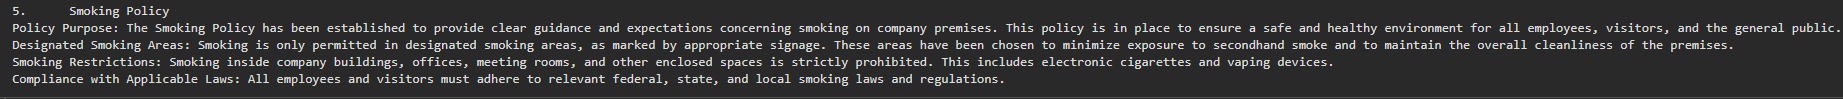

Exercise 1
<p>
Retrieve Top 2 Results Using a Vector Store-Backed Retriever

In [37]:
vectordb = Chroma.from_documents(documents=chunks_txt, embedding=watsonx_embedding())
retriever = vectordb.as_retriever(search_kwargs={"k": 2})
query = "smoking policy"
docs = retriever.invoke(query)
docs

ValidationError: 1 validation error for WatsonxEmbeddings
__root__
  Did not find apikey, please add an environment variable `WATSONX_APIKEY` which contains it, or pass `apikey` as a named parameter. (type=value_error)

Exercise 2
<p>
Self-Querying Retriever for a Query

In [38]:
# You might encouter some errors or blank content when run the following code.
# It is becasue LLM cannot get the answer at first. Don't worry, re-run it several times you will get the answer.

vectordb = Chroma.from_documents(docs, watsonx_embedding())

retriever = SelfQueryRetriever.from_llm(
    llm(),
    vectordb,
    document_content_description,
    metadata_field_info,
)

# This example specifies a query with filter
retriever.invoke(
    "I want to watch a movie directed by Christopher Nolan"
)

ValidationError: 1 validation error for WatsonxEmbeddings
__root__
  Did not find apikey, please add an environment variable `WATSONX_APIKEY` which contains it, or pass `apikey` as a named parameter. (type=value_error)